# Blazar Population ML – Part 2: Apparent Jet Velocity Regression (MOJAVE Cross-Match)

**Table of Content**

12. [Introduction – Part 2](#12-introduction)
13. Setup and imports
14. EDA – Part 2
15. Regression Setup
16. Regression Methods Comparison
17. Uncertainty Quantification

## 12. Introduction

### About this Project – Part 2

[Part 1](./blazar_population_ml-p1.ipynb) established the cluster geometry of the full 4LAC-DR3 blazar population and assigned probabilistic classifications to BCU sources using unsupervised methods. Part 2 (this notebook) shifts to supervised regression: given the 334-source MOJAVE-matched subsample, can a model predict the apparent jet velocity $\log \beta_{\rm app}$ from purely observational SED features?

The feature set expands beyond [Part 1](./blazar_population_ml-p1.ipynb). Appended kinematic observables $\beta_{\rm app}$ and $\Gamma_{\rm min} = \sqrt{1 + \beta_{\rm app}^2}$ from MOJAVE-XVII (Lister et al. 2021) are the same quantities used in the forward model of Rueda-Becerril, Harrison & Giannios (2021, RHG21 hereafter). This is the direct observational link between the simulation constraints and the data-driven approach.

**Scientific question:** Does the 4LAC-DR3 SED feature space encode sufficient information to predict the apparent jet velocity $\log \beta_{\rm app}$ in MOJAVE-detected blazars? If so, which SED features carry the predictive signal, and does that signal survive within individual blazar classes or is it entirely driven by the FSRQ/BL Lac dichotomy? The question of recovering the baryon loading $\mu$ directly from observations is addressed in [Part 3](./blazar_population_ml-p3.ipynb), where Tleco pseudo-labels provide the necessary $\mu$ supervision.

### Connection to Part 1

Part 1 demonstrated that the 4LAC-DR3 SED feature space is strongly stratified by CLASS. The UMAP embedding (Sec. 9) showed a clear geometric separation between FSRQs and BL Lacs driven primarily by $\log \nu_{\rm syn}$ and Compton dominance — the same features that encode the FSRQ/BL Lac spectral dichotomy. BCU sources were classified in Part 1 by their proximity to these clusters (Sec. 10), and the classification posteriors are well-separated because the two classes occupy compact, non-overlapping regions of feature space.

This has a direct consequence for Part 2. FSRQs have systematically higher $\beta_{\rm app}$ than BL Lacs; any model that learns to predict high velocities for FSRQ-like SEDs and low velocities for BL Lac-like SEDs will report non-trivial $R^2$ and Spearman $\rho$ without learning anything about individual-source jet dynamics. Global metrics conflate CLASS-level trend and individual-source predictability. The same lesson emerged in Part 1 when evaluating BCU classifier performance: aggregate accuracy inflated by class imbalance misrepresents individual-source discrimination. The same logic applies here.

The scientific question is therefore layered: first, whether the global correlation exists and which features drive it; second, and more importantly, whether any signal survives within individual classes after the CLASS-label signal has been removed by design.

### Analytic Design

**Layer 1 — Global method comparison (Sec. 16).** Four regression methods spanning the spectrum from linear to Bayesian — Ridge, Random Forest (RF), Gradient Boosting (GBM), and Gaussian Process Regression (GPR) with Automatic Relevance Determination (ARD) Radial Basis Function (RBF) kernel — are fit on the combined sample. This establishes the global signal ceiling, reveals which model generalizes best, and flags overfitting. All models are evaluated on the same stratified 80/20 split using RMSE, mean absolute error (MAE), $R^2$, and Spearman rank correlation $\rho$.

**Layer 2 — Within-class regression (Sec. 16).** Ridge, RF, and GBM are refit separately on FSRQ and BL Lac subsamples using 5-fold cross-validation (CV). GPR is excluded from the within-class CV: with fewer sources per fold and no inter-class signal to exploit, the ARD RBF kernel fails to converge — a result that is itself informative and is discussed below. A per-class GPR is fit separately on the full class data for ARD inspection only. If within-class $\rho$ collapses relative to global $\rho$, the CLASS label carries the kinematic information and SED features serve as proxies for class membership rather than individual jet dynamics.

**Layer 3 — Feature importance consensus (Sec. 16).** RF and GBM split importances and GPR ARD length scales are compared globally and per class. If features that dominate globally (e.g., $\alpha_{\rm LP}$ and $A_C$) lose importance within classes, they are encoding CLASS membership, not individual-source kinematic variation.

**Layer 4 — Uncertainty quantification (Sec. 17).** Three interval methods — GPR posterior (Bayesian), quantile regression via GBM (frequentist, non-parametric), and bootstrap intervals via RF (frequentist, resampling) — are compared on calibration and interval width.

## 13. Setup and Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

# Paths
DATA_DIR = Path("data/")
LAC_H = DATA_DIR / "table-4LAC-DR3-h.fits"
MOJAVE = DATA_DIR / "VizieR-MOJAVE-XVII.fit"

# Plot style
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
CLASS_COLORS = {"bll": "steelblue", "fsrq": "tomato", "bcu": "green"}
SED_COLORS = {"lsp": "tomato", "isp": "goldenrod", "hsp": "steelblue"}

In [18]:
# Load Part 2 parquet
matched_df = pd.read_parquet("data/part2_4lac_mojave.parquet")
print(matched_df.info())
matched_df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_name      334 non-null    str    
 1   mojave_id        334 non-null    str    
 2   class            334 non-null    str    
 3   sed_class        334 non-null    str    
 4   redshift         301 non-null    float64
 5   pl_index         334 non-null    float64
 6   lp_alpha         334 non-null    float64
 7   lp_beta          334 non-null    float64
 8   log_nu_syn       327 non-null    float64
 9   log_nuFnu_syn    327 non-null    float64
 10  log_he_epeak     318 non-null    float64
 11  log_compton_dom  312 non-null    float64
 12  log_gamma_lum    301 non-null    float64
 13  var_index        334 non-null    float64
 14  frac_var         320 non-null    float64
 15  beta_app         334 non-null    float64
 16  e_beta           334 non-null    float64
 17  gamma_min        334 non-nu

,redshift,pl_index,lp_alpha,lp_beta,log_nu_syn,log_nuFnu_syn,log_he_epeak,log_compton_dom,log_gamma_lum,var_index,frac_var,beta_app,e_beta,gamma_min,sep_arcsec
count,301.00,334.00,334.00,334.00,327.00,327.00,318.00,312.00,301.00,334.00,320.00,334.00,334.00,334.00,334.00
mean,0.93,2.33,2.26,0.10,13.10,-11.41,2.36,0.14,46.51,1508.43,0.68,7.92,0.82,8.27,0.01
std,0.64,0.23,0.25,0.09,0.80,0.47,0.86,0.49,1.14,6727.74,0.38,8.69,1.03,8.41,0.03
min,0.00,1.68,1.57,-0.11,11.32,-12.49,-0.51,-1.50,41.81,4.95,0.03,0.00,0.00,1.00,0.00
25%,0.42,2.19,2.11,0.06,12.62,-11.73,1.96,-0.20,45.95,55.33,0.41,0.22,0.05,1.02,0.01
50%,0.86,2.34,2.26,0.09,12.92,-11.46,2.30,0.09,46.72,264.32,0.60,5.34,0.52,5.43,0.01
75%,1.34,2.48,2.42,0.12,13.30,-11.13,2.76,0.47,47.25,900.23,0.89,12.56,1.10,12.60,0.02
max,3.10,2.90,3.03,1.00,16.34,-9.66,6.12,1.84,48.68,84340.76,2.29,41.50,7.30,41.51,0.54


In [19]:
print(f"\nCLASS breakdown:")
print(matched_df["class"].value_counts())

print(f'\nbeta_app = 0 sources: {(matched_df["beta_app"] == 0).sum()}')

print(f'\ngamma_min stats:\n{matched_df["gamma_min"].describe().round(2)}')


CLASS breakdown:
class
fsrq     200
bll      110
rdg        8
bcu        8
nlsy1      4
css        2
agn        1
ssrq       1
Name: count, dtype: int64

beta_app = 0 sources: 71

gamma_min stats:
count    334.00
mean       8.27
std        8.41
min        1.00
25%        1.02
50%        5.43
75%       12.60
max       41.51
Name: gamma_min, dtype: float64


## 14. Exploratory Data Analysis

The MOJAVE-XVII cross-match introduces a strong kinematic selection bias: MOJAVE targets bright, compact, flat-spectrum sources with high apparent velocities, which preferentially selects FSRQs and low-frequency-peaked BL Lacs over the high-synchrotron-peaked (HSP) population. Before proceeding to regression, we characterize this bias explicitly. Since the regression model will be trained on this subsample, the generalizability of any recovered $\log \beta_{\rm app}$ prediction depends directly on how representative the subsample is of the full blazar population.

In [20]:
# Load pca_df for UMAP overlay and catalog-level KDE
pca_df = pd.read_parquet("data/pca_catalog.parquet")
pca_df["in_mojave"] = pca_df["source_name"].isin(matched_df["source_name"])
mojave_in_pca = pca_df[pca_df["in_mojave"]]

# Build full palette: known classes get CLASS_COLORS
_all_cls = matched_df["class"].unique()
_palette = {cls: CLASS_COLORS.get(cls, "gray") for cls in _all_cls}

### 1. $\Gamma_{\rm min}$ distribution by CLASS

FSRQs are expected to dominate the high-$\Gamma_{\rm min}$ tail, reflecting the MOJAVE kinematic selection threshold.

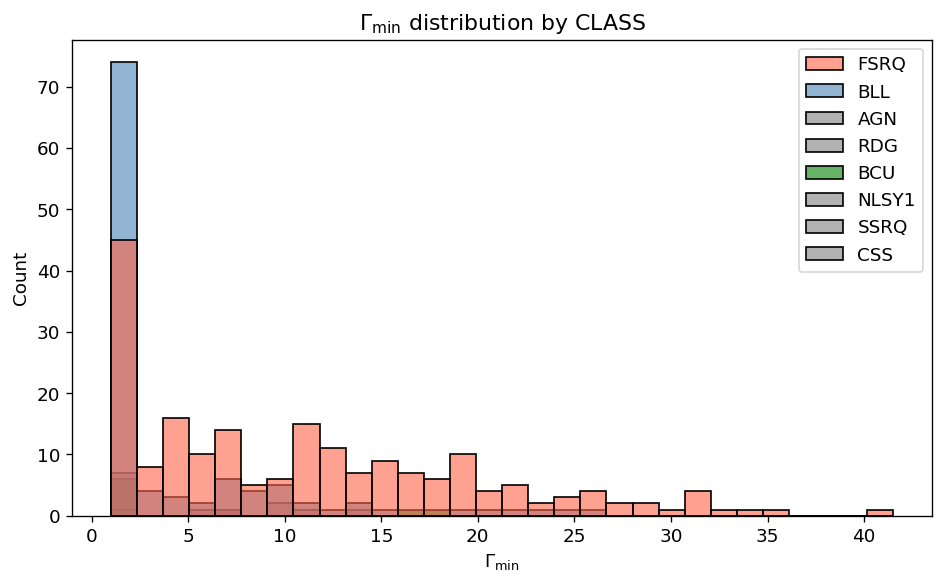

In [21]:
# 1. gamma_min by CLASS
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=matched_df,
    x="gamma_min",
    hue="class",
    bins=30,
    alpha=0.6,
    multiple="layer",
    palette=_palette,
    ax=ax,
)
leg = ax.get_legend()
leg.set_title("")
for t in leg.get_texts():
    t.set_text(t.get_text().upper())
ax.set_xlabel(r"$\Gamma_{\rm min}$")
ax.set_ylabel("Count")
ax.set_title(r"$\Gamma_{\rm min}$ distribution by CLASS")

plt.tight_layout()
plt.show()

### 2. $\beta_{\rm app}$ vs. $\log \nu_{\rm syn}$

The kinematic-SED anti-correlation expected from the blazar sequence and the RHG21 model.

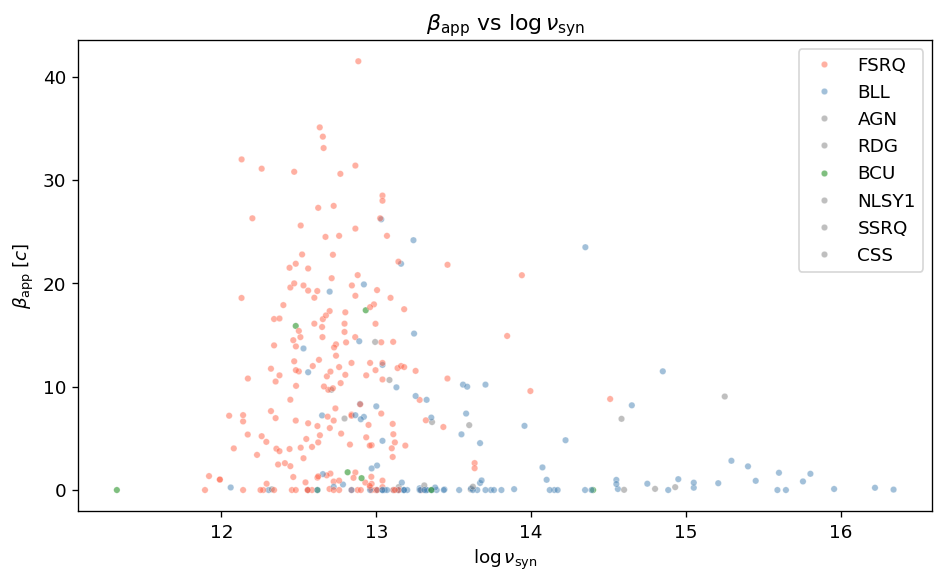

In [22]:
# 2. beta_app vs log_nu_syn
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=matched_df,
    x="log_nu_syn",
    y="beta_app",
    hue="class",
    s=15,
    alpha=0.5,
    palette=_palette,
    ax=ax,
)
leg = ax.get_legend()
leg.set_title("")
for t in leg.get_texts():
    t.set_text(t.get_text().upper())
ax.set_xlabel(r"$\log \nu_{\rm syn}$")
ax.set_ylabel(r"$\beta_{\rm app}\;[c]$")
ax.set_title(r"$\beta_{\rm app}$ vs $\log\nu_{\rm syn}$")

plt.tight_layout()
plt.show()

### 3. Part 2 sources in the Part 1 UMAP embedding

Whether the MOJAVE subsample occupies the full parameter space or is concentrated in the FSRQ/low-synchrotron-peaked (LSP) region.

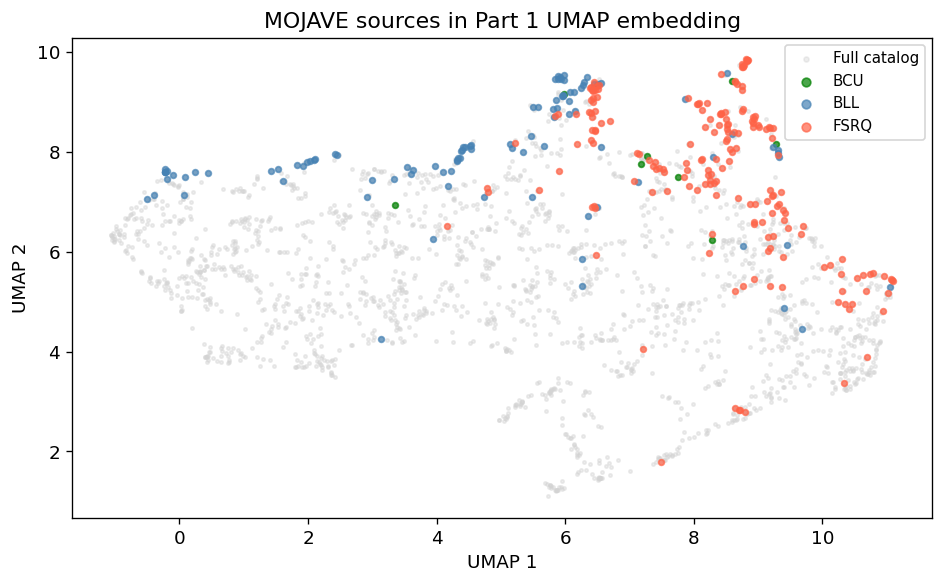

In [23]:
# 3. UMAP overlay: full catalog + MOJAVE subsample
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    pca_df["UMAP1"],
    pca_df["UMAP2"],
    c="lightgray",
    s=4,
    alpha=0.4,
    rasterized=True,
    label="Full catalog",
)
for cls, grp in mojave_in_pca.groupby("class"):
    ax.scatter(
        grp["UMAP1"],
        grp["UMAP2"],
        s=12,
        alpha=0.7,
        color=CLASS_COLORS.get(cls, "gray"),
        label=cls.upper(),
    )
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("MOJAVE sources in Part 1 UMAP embedding")
ax.legend(markerscale=1.5, fontsize=9)

plt.tight_layout()
plt.show()

### 4. $\log \nu_{\rm syn}$ distribution, MOJAVE subsample vs. full 4LAC-DR3 complete-case catalog

The feature most sensitive to the FSRQ/BL Lac split and the primary observable linking the blazar sequence to the baryon loading constraint.

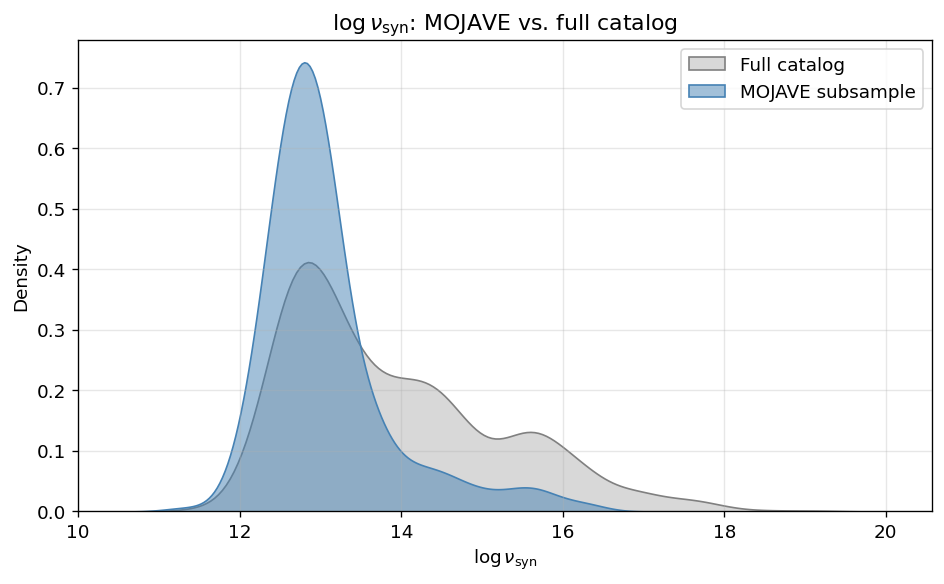

In [24]:
# 4. log_nu_syn KDE: full catalog vs MOJAVE subsample
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(
    data=pca_df,
    x="log_nu_syn",
    fill=True,
    alpha=0.3,
    color="gray",
    label="Full catalog",
    ax=ax,
)
sns.kdeplot(
    data=mojave_in_pca,
    x="log_nu_syn",
    fill=True,
    alpha=0.5,
    color="steelblue",
    label="MOJAVE subsample",
    ax=ax,
)
ax.set_xlabel(r"$\log \nu_{\rm syn}$")
ax.set_ylabel("Density")
ax.set_title(r"$\log \nu_{\rm syn}$: MOJAVE vs. full catalog")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Diagnostic

The four diagnostics confirm a pronounced selection bias in the MOJAVE subsample:

- **Panel 1**: FSRQs dominate the high-$\Gamma_{\rm min}$ tail, as expected from MOJAVE's kinematic threshold, corresponding to bright, fast-moving jets associated with high-accretion-rate sources.
- **Panel 2**: The $\beta_{\rm app}$ vs. $\log \nu_{\rm syn}$ scatter reproduces the anti-correlation predicted by the blazar sequence and the RHG21 model, with FSRQs clustering at low $\log \nu_{\rm syn}$ and high apparent velocities, and BL Lacs at high $\log \nu_{\rm syn}$ and low $\beta_{\rm app}$.
- **Panel 3**: The Uniform Manifold Approximation and Projection (UMAP) overlay makes the spatial extent of this bias explicit, i.e., the MOJAVE sources are heavily concentrated in the FSRQ/LSP region (see Sec. 9.3 in [Part 1](./blazar_population_ml-p1.ipynb)) embedding and largely absent from the HSP BL Lac locus.
- **Panel 4**: The $\log \nu_{\rm syn}$ kernel density estimate shows that while both distributions share a similar peak, the MOJAVE subsample is narrower and systematically underrepresents the high-$\log \nu_{\rm syn}$ tail where HSP BL Lacs reside.

In addition, we found in [Part 1](./blazar_population_ml-p1.ipynb) that out of the 334 MOJAVE-matched sources, 300 have complete-case Principal Component Analysis (PCA) features and therefore appear in the UMAP embedding. The remaining 34 were dropped in Sec. 7 "Missingness Audit" in Part 1.

The consequence for regression is direct: the model will be trained on a sample that is roughly 60% FSRQs and undersamples the HSP BL Lac population by a large margin. Predictions for high-$\log \nu_{\rm syn}$ sources should be treated as extrapolations beyond the training distribution. This limitation does not invalidate the regression, but it must be stated explicitly when interpreting whether the recovered $\log \beta_{\rm app}$ predictions generalize to the full blazar population.

## 15. Regression Setup

### Target Variable

The regression target is $\log \beta_{\rm app}$, the base-10 logarithm of the apparent jet velocity. $\beta_{\rm app}$ is a direct Very Long Baseline Interferometry (VLBI) measurement from MOJAVE-XVII, not a derived quantity. The log transform is applied for two reasons: (1) $\beta_{\rm app}$ ranges from sub-luminal values to $\sim 40c$, producing a strongly right-skewed distribution; (2) the RHG21 physical picture is formulated in terms of $\Gamma$, which relates to $\beta_{\rm app}$ monotonically, and the $\dot{m}$-$\Gamma$ empirical relation is a power law, so log space is the natural scale for the regression.

Sources with $\beta_{\rm app} = 0$ are excluded: 71 such sources have no detected superluminal motion in MOJAVE, making $\log \beta_{\rm app}$ undefined. These are not slow jets; they are sources where MOJAVE resolved no moving components above the detection threshold, and their exclusion is a data quality cut, not a physical selection.

The baryon loading $\mu$ is not directly observable and has no catalog labels. Recovering $\mu$ requires Tleco pseudo-labels generated from a physical model grid. This is addressed in [Part 3](./blazar_population_ml-p3.ipynb).

### Feature Set

We use seven SED features: the same catalog-native features from Part 1. $\beta_{\rm app}$ and $\Gamma_{\rm min}$ are excluded from the feature set: $\beta_{\rm app}$ is the regression target and $\Gamma_{\rm min} = \sqrt{1 + \beta_{\rm app}^2}$ is a deterministic transform of it. Sources missing any of the seven SED features are dropped (complete-case).

In [25]:
# Seven SED features: the same catalog-native features used in Part 1.
# beta_app and gamma_min are excluded: beta_app is the regression target,
# and gamma_min = sqrt(1 + beta_app^2) is a deterministic transform of it.
reg_feats = [
    "pl_index",
    "lp_alpha",
    "lp_beta",
    "log_nu_syn",
    "log_nuFnu_syn",
    "log_compton_dom",
    "var_index",
]
TARGET = "log_beta_app"

# Exclude beta_app = 0 sources: log(0) is undefined and these sources have
# no detected superluminal motion in MOJAVE (data quality cut, not physical).
reg_df = matched_df[matched_df["beta_app"] > 0].copy()
reg_df["log_beta_app"] = np.log10(reg_df["beta_app"])
print(f'Removed {(matched_df["beta_app"] == 0).sum()} sources with beta_app=0')
print(f'log_beta_app range: [{reg_df["log_beta_app"].min():.2f}, {reg_df["log_beta_app"].max():.2f}]')

# Complete-case filter on SED features
reg_mask = reg_df[reg_feats].notna().all(axis=1)
reg_df = reg_df[reg_mask].reset_index(drop=True)
print(f"Regression sample (complete cases): {len(reg_df)} sources")
print(f'CLASS breakdown:\n{reg_df["class"].value_counts()}')

Removed 71 sources with beta_app=0
log_beta_app range: [-1.71, 1.62]
Regression sample (complete cases): 246 sources
CLASS breakdown:
class
fsrq     168
bll       62
rdg        5
nlsy1      4
bcu        4
css        2
ssrq       1
Name: count, dtype: int64


### Train/Test Split

With ~246 usable sources after exclusions, an 80/20 stratified split by CLASS gives a test set of ~49 sources. This is small enough that reported metrics will have high variance; confidence intervals on all scores are reported via bootstrap where applicable.

An alternative is leave-one-out cross-validation (LOO-CV), which uses every observation once as a test point and is nearly unbiased at this sample size. For Gaussian Process Regression (GPR), LOO-CV is computationally tractable and preferred. For Random Forest, 5-fold cross-validation is the practical choice.

Both approaches are implemented below. The primary evaluation metric is root mean squared error (RMSE) on $\log \beta_{\rm app}$ and the calibration of predictive uncertainty intervals.

**Note on stratification.** The MOJAVE cross-match contains rare source classes beyond BLL, FSRQ, and BCU (`agn`, `ssrq` with fewer than 2 members each). Passing `stratify=classes` directly to `train_test_split` raises a `ValueError` because sklearn requires at least 2 members per stratum. Collapsing rare classes into `"other"` before stratifying is the correct fix: it preserves proportional CLASS balance for the three main classes, which matter because $\log \beta_{\rm app}$ correlates strongly with CLASS (FSRQs systematically show higher apparent velocities than BL Lacs). Dropping stratification entirely (`stratify=None`) is simpler but risks a skewed split that inflates or deflates reported metrics.

In [26]:
# Arrays for sklearn
X = reg_df[reg_feats].values
y = reg_df[TARGET].values
classes = reg_df["class"].to_numpy()

# Rare classes (agn, ssrq) have <2 members and raise ValueError if we split with
# stratify=classes.
# Collapsing them into 'other' class so main classes (bll, fsrq, bcu) remain stratified
_counts = pd.Series(classes).value_counts()
strat_key = np.where(np.isin(classes, _counts[_counts >= 3].index), classes, "other")

# 80/20 split stratified on main classes
X_train, X_test, y_train, y_test, cls_train, cls_test = train_test_split(
    X, y, classes, test_size=0.2, random_state=42, stratify=strat_key
)

# Standardize features (GPR and RF are scale-sensitive)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Verify split and class balance
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train CLASS breakdown: {dict(zip(*np.unique(cls_train, return_counts=True)))}")
print(f"Test CLASS breakdown:  {dict(zip(*np.unique(cls_test, return_counts=True)))}")

Train: 196 | Test: 50
Train CLASS breakdown: {'bcu': np.int64(3), 'bll': np.int64(50), 'css': np.int64(1), 'fsrq': np.int64(134), 'nlsy1': np.int64(3), 'rdg': np.int64(4), 'ssrq': np.int64(1)}
Test CLASS breakdown:  {'bcu': np.int64(1), 'bll': np.int64(12), 'css': np.int64(1), 'fsrq': np.int64(34), 'nlsy1': np.int64(1), 'rdg': np.int64(1)}


## 16. Regression Methods Comparison

### 16.1 Global Baseline

The global regression uses the full 246-source sample as the baseline. Its purpose is not to produce the main scientific result — the within-class analysis in Sec. 16.2 does that — but to establish the total signal ceiling available in the mixed-class sample and to diagnose method behavior before stratifying.

Four methods spanning the spectrum from linear to Bayesian are compared:

- **Ridge regression**: a regularized linear model that tests whether the SED-kinematic relationship is approximately linear in standardized feature space.
- **Random Forest (RF)**: a non-parametric ensemble; captures non-linear interactions; provides mean decrease in impurity (MDI) feature importances.
- **Gradient Boosting (GBM)**: a sequential ensemble; typically the strongest tabular point predictor; also used for quantile regression in Sec. 17. With $n_{\rm train} = 196$ sources, GBM overfitting is a real risk.
- **GPR with ARD RBF kernel**: provides a posterior predictive distribution and identifies feature relevance through kernel length scales.

Performance is reported as RMSE, $R^2$ (fraction of variance explained), and Spearman rank correlation $\rho$. A negative $R^2$ means the model is worse than predicting the sample mean — a sign of overfitting. All four models are evaluated on the same 80/20 held-out test set (50 sources).

In [27]:
n_feats = len(reg_feats)
_kernel = ConstantKernel(1.0) * RBF(length_scale=np.ones(n_feats)) + WhiteKernel(noise_level=0.1)

models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1),
    "GBM": GradientBoostingRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42
    ),
    "GPR": GaussianProcessRegressor(
        kernel=_kernel, n_restarts_optimizer=10, normalize_y=True, random_state=42
    ),
}

preds = {}
results = []

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    preds[name] = y_pred
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = float(np.mean(np.abs(y_test - y_pred)))
    r2 = 1 - np.sum((y_test - y_pred) ** 2) / np.sum((y_test - y_test.mean()) ** 2)
    rho, pval = spearmanr(y_test, y_pred)
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R²": r2, "Spearman ρ": rho, "p": pval})

results_df = pd.DataFrame(results).set_index("Model")
print(results_df[["RMSE", "MAE", "R²", "Spearman ρ", "p"]].round(3).to_string())

               RMSE    MAE     R²  Spearman ρ      p
Model                                               
Ridge         0.513  0.403  0.238       0.341  0.015
RandomForest  0.566  0.422  0.073       0.314  0.027
GBM           0.629  0.447 -0.143       0.279  0.050
GPR           0.570  0.413  0.062       0.288  0.043


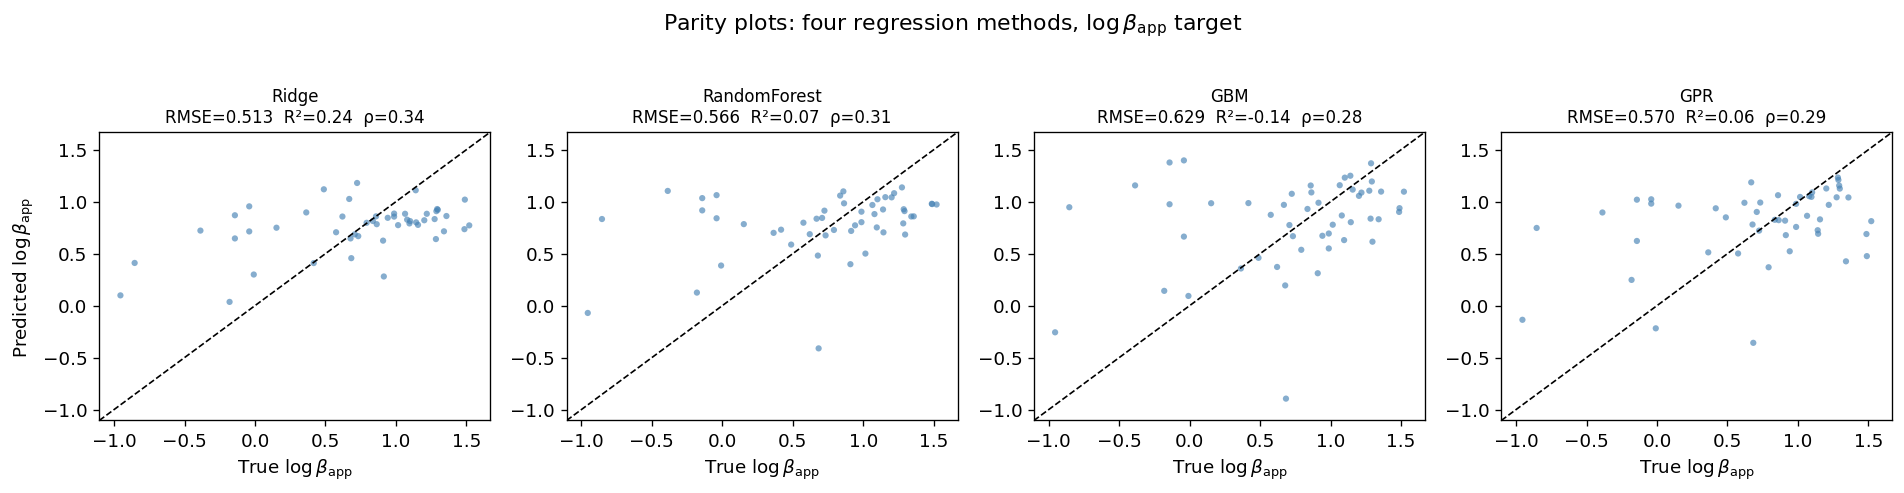

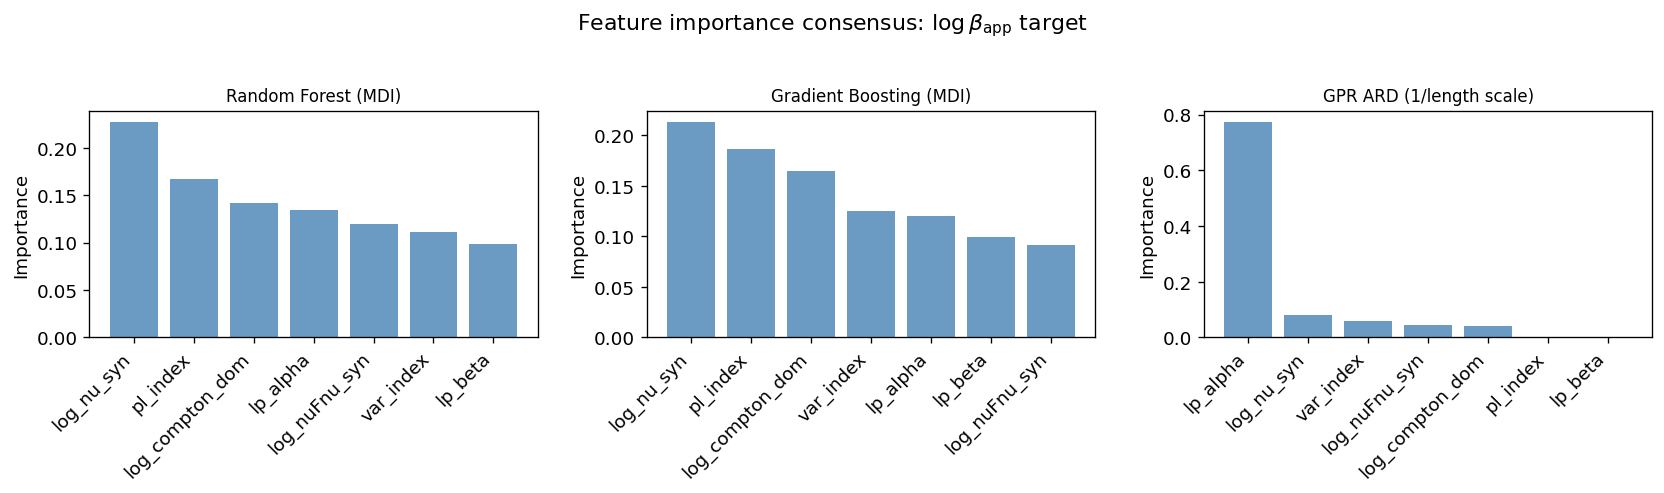

In [28]:
# ── Parity plots: all four methods ────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_test, y_pred, s=14, alpha=0.65, color="steelblue", edgecolors="none")
    lim = [
        min(y_test.min(), y_pred.min()) - 0.15,
        max(y_test.max(), y_pred.max()) + 0.15,
    ]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    r2 = results_df.loc[name, "R²"]
    rho = results_df.loc[name, "Spearman ρ"]
    rmse = results_df.loc[name, "RMSE"]
    ax.set_title(f"{name}\nRMSE={rmse:.3f}  R²={r2:.2f}  ρ={rho:.2f}", fontsize=10)
    ax.set_xlabel(r"True $\log \beta_{\rm app}$")
    if ax is axes[0]:
        ax.set_ylabel(r"Predicted $\log \beta_{\rm app}$")

plt.suptitle(r"Parity plots: four regression methods, $\log \beta_{\rm app}$ target", y=1.02)
plt.tight_layout()
plt.show()

# ── Feature importance consensus ──────────────────────────────────────────────
def _find_rbf(kernel):
    if isinstance(kernel, RBF):
        return [kernel]
    result = []
    for attr in ("k1", "k2"):
        sub = getattr(kernel, attr, None)
        if sub is not None:
            result += _find_rbf(sub)
    return result

imp_rf = models["RandomForest"].feature_importances_
imp_gbm = models["GBM"].feature_importances_
rbf_kernels = _find_rbf(models["GPR"].kernel_)
imp_gpr = 1.0 / rbf_kernels[0].length_scale
imp_gpr /= imp_gpr.sum()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (title, imp) in zip(
    axes,
    [
        ("Random Forest (MDI)", imp_rf),
        ("Gradient Boosting (MDI)", imp_gbm),
        ("GPR ARD (1/length scale)", imp_gpr),
    ],
):
    order = np.argsort(imp)[::-1]
    ax.bar(range(len(reg_feats)), imp[order], color="steelblue", alpha=0.8)
    ax.set_xticks(range(len(reg_feats)))
    ax.set_xticklabels([reg_feats[i] for i in order], rotation=45, ha="right")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Importance")

plt.suptitle(r"Feature importance consensus: $\log \beta_{\rm app}$ target", y=1.02)
plt.tight_layout()
plt.show()

### 16.2 Within-Class Regression

The global results in Sec. 16.1 must be interpreted with caution. Ridge achieves $R^2 = 0.24$ and Spearman $\rho \approx 0.34$ (p = 0.015 on 50 test sources), while GBM produces a negative $R^2$, meaning it is worse than predicting the mean — a clear sign of overfitting on 196 training samples. The fact that Ridge, the most constrained linear model, is the best predictor already suggests the non-linear methods are fitting noise rather than signal.

More fundamentally, the global $\rho \approx 0.30$–$0.34$ is confounded by CLASS structure. As Part 1 established (Sec. 9), FSRQs and BL Lacs occupy distinct, compact clusters in SED feature space. Since FSRQs also have systematically higher $\beta_{\rm app}$ than BL Lacs, a model that learns nothing more than the CLASS label can produce a positive global $\rho$. The within-class regression strips this free signal away.

We refit Ridge, RF, and GBM separately on FSRQs (168 sources) and BL Lacs (62 sources) using 5-fold cross-validation. GPR is excluded from the within-class CV for a principled reason: without the inter-class $\log \nu_{\rm syn}$ gradient to anchor the RBF kernel, the ARD optimizer drives the noise level to its lower bound ($\approx 10^{-5}$, interpolating the training fold rather than regressing it) and pushes most length scales to their upper bound ($10^5$, treating those features as constant). This is not a numerical accident — it is the kernel's way of reporting that there is no structured covariance to learn. We treat it as a GPR-specific diagnostic and discuss the ARD length scales from a separate full-class fit below.

For the three CV methods, each pipeline standardizes features within its own training fold, ensuring no cross-fold leakage.

In [29]:
import warnings
from sklearn.exceptions import ConvergenceWarning

def _make_pipelines():
    """Ridge, RF, GBM pipelines for per-class 5-fold CV.
    GPR is excluded: the ARD kernel does not converge within a single class
    (noise_level → lower bound, most length_scales → upper bound).
    This is itself a diagnostic result; see the full-class ARD fits below.
    """
    return {
        "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
        "RandomForest": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
        ]),
        "GBM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GradientBoostingRegressor(
                n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42
            )),
        ]),
    }

CLASS_SUBSETS = {
    "FSRQ":   reg_df[reg_df["class"] == "fsrq"].reset_index(drop=True),
    "BL Lac": reg_df[reg_df["class"] == "bll"].reset_index(drop=True),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
per_class_results = []
per_class_gpr = {}  # full-class GPR for ARD inspection (not CV performance)

for cls_name, cls_df in CLASS_SUBSETS.items():
    X_cls = cls_df[reg_feats].values
    y_cls = cls_df[TARGET].values

    # ── 5-fold CV: Ridge, RF, GBM ─────────────────────────────────────────────
    for model_name, pipe in _make_pipelines().items():
        y_cv = cross_val_predict(pipe, X_cls, y_cls, cv=kf)
        rmse = np.sqrt(mean_squared_error(y_cls, y_cv))
        mae  = float(np.mean(np.abs(y_cls - y_cv)))
        r2   = 1 - np.sum((y_cls - y_cv)**2) / np.sum((y_cls - y_cls.mean())**2)
        rho, pval = spearmanr(y_cls, y_cv)
        per_class_results.append({
            "Class": cls_name, "Model": model_name, "n": len(y_cls),
            "RMSE": rmse, "MAE": mae, "R²": r2, "Spearman ρ": rho, "p": pval,
        })

    # ── Full-class GPR for ARD (in-sample, interpretability only) ─────────────
    _sc  = StandardScaler().fit(X_cls)
    _gpr = GaussianProcessRegressor(
        kernel=ConstantKernel(1.0) * RBF(length_scale=np.ones(n_feats)) + WhiteKernel(noise_level=0.1),
        n_restarts_optimizer=10, normalize_y=True, random_state=42,
    )
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        _gpr.fit(_sc.transform(X_cls), y_cls)
    per_class_gpr[cls_name] = (_sc, _gpr)

    # Print ARD diagnostic explicitly (what the ConvergenceWarnings encode)
    rbf_k  = _find_rbf(_gpr.kernel_)
    ls     = rbf_k[0].length_scale
    noise  = _gpr.kernel_.k2.noise_level
    print(f"\n{cls_name} GPR ARD diagnostic (in-sample, n={len(y_cls)}):")
    print(f"  noise_level = {noise:.2e}"
          + ("  ← at lower bound: GPR interpolating, no residual noise" if noise < 1e-3 else ""))
    for feat, l in zip(reg_feats, ls):
        flag = "  ← at upper bound: zero signal within class" if l > 1e4 else ""
        print(f"  {feat:<22}  ls = {l:.3e}{flag}")

per_class_df = pd.DataFrame(per_class_results)
print("\n── 5-fold CV metrics by CLASS (Ridge, RF, GBM) ──────────────────────")
print(per_class_df.set_index(["Class", "Model"])[["n", "RMSE", "R²", "Spearman ρ", "p"]].round(3).to_string())

# ── Global vs. within-class R² comparison ─────────────────────────────────────
cv_models = ["Ridge", "RandomForest", "GBM"]
print("\n── R² comparison: global (test set) vs. within-class (5-fold CV) ──────")
cmp = pd.DataFrame({
    "Global":  results_df.loc[cv_models, "R²"].round(3),
    "FSRQ":    per_class_df[per_class_df["Class"] == "FSRQ"].set_index("Model")["R²"].round(3),
    "BL Lac":  per_class_df[per_class_df["Class"] == "BL Lac"].set_index("Model")["R²"].round(3),
})
print(cmp.to_string())


FSRQ GPR ARD diagnostic (in-sample, n=168):
  noise_level = 1.00e-05  ← at lower bound: GPR interpolating, no residual noise
  pl_index                ls = 1.000e+05  ← at upper bound: zero signal within class
  lp_alpha                ls = 2.030e-01
  lp_beta                 ls = 1.829e-01
  log_nu_syn              ls = 6.163e-02
  log_nuFnu_syn           ls = 8.284e-02
  log_compton_dom         ls = 1.029e+03
  var_index               ls = 1.000e+05  ← at upper bound: zero signal within class

BL Lac GPR ARD diagnostic (in-sample, n=62):
  noise_level = 1.00e-05  ← at lower bound: GPR interpolating, no residual noise
  pl_index                ls = 1.000e+05  ← at upper bound: zero signal within class
  lp_alpha                ls = 2.016e-01
  lp_beta                 ls = 4.871e-01
  log_nu_syn              ls = 3.012e+03
  log_nuFnu_syn           ls = 1.046e+00
  log_compton_dom         ls = 4.315e-01
  var_index               ls = 7.213e+03

── 5-fold CV metrics by CLASS (Ridge, RF

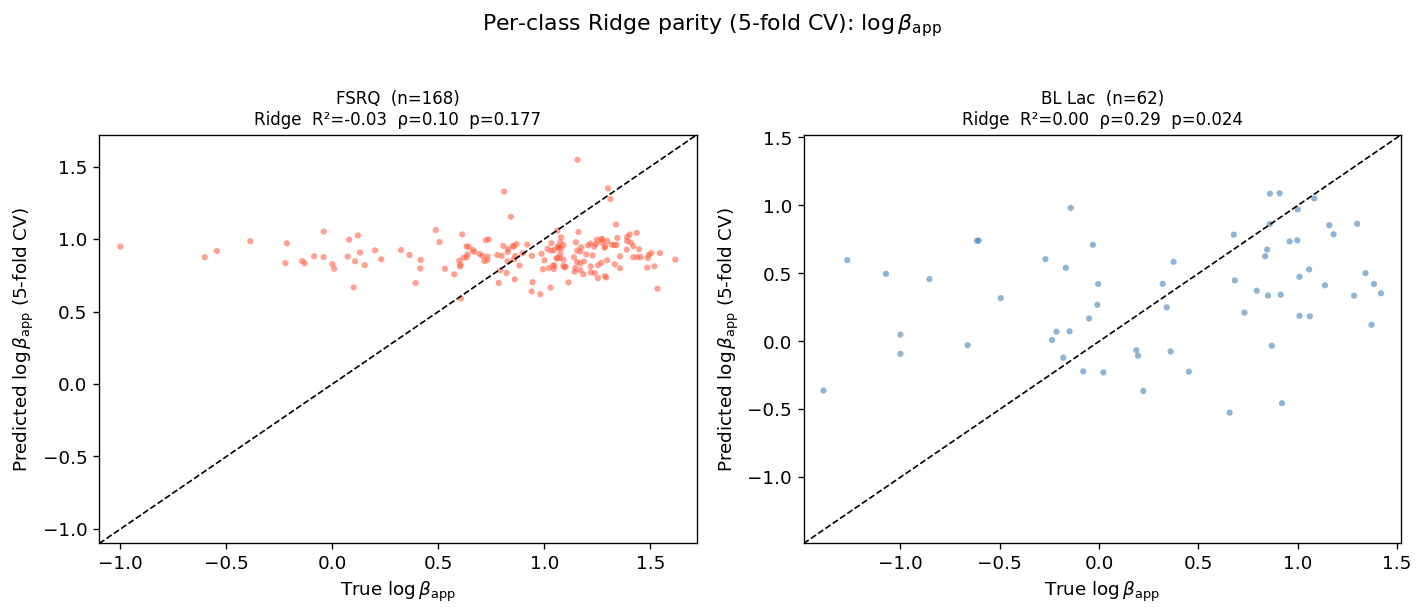

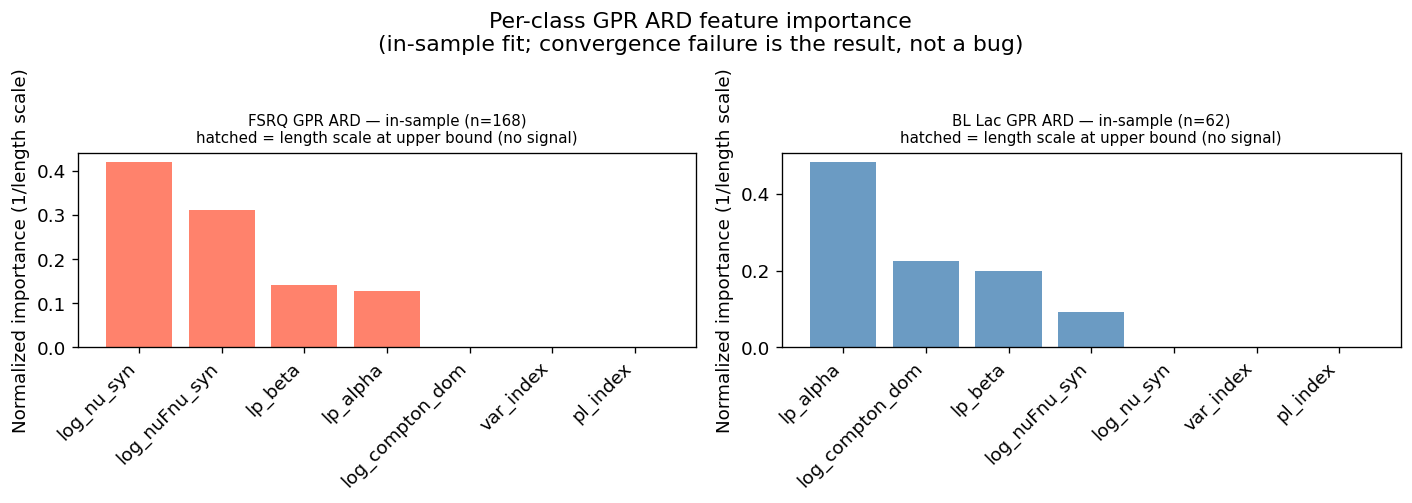

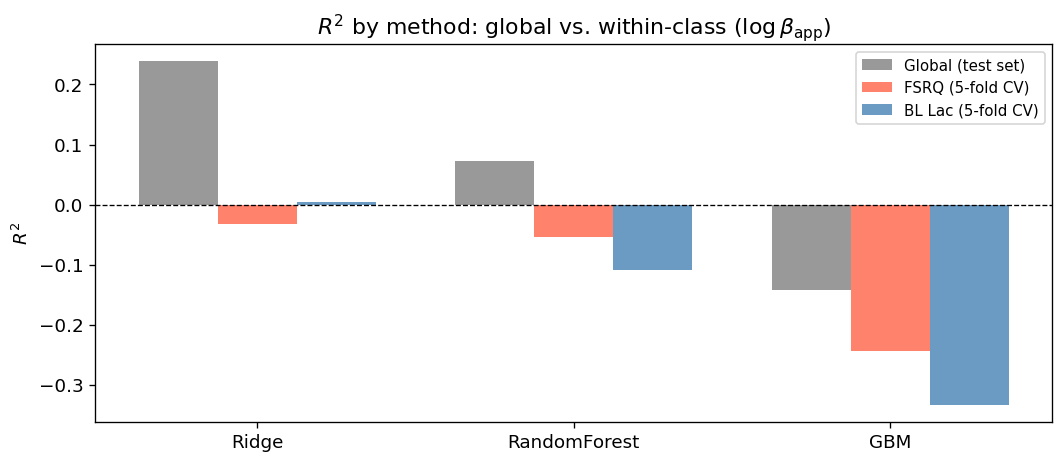

In [30]:
cls_color = {"FSRQ": "tomato", "BL Lac": "steelblue"}
cls_n = {cls_name: len(cls_df) for cls_name, cls_df in CLASS_SUBSETS.items()}

# ── Per-class parity: Ridge (best CV model within class) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (cls_name, cls_df) in zip(axes, CLASS_SUBSETS.items()):
    X_cls = cls_df[reg_feats].values
    y_cls = cls_df[TARGET].values
    _ridge_pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])
    y_cv_ridge  = cross_val_predict(_ridge_pipe, X_cls, y_cls, cv=kf)
    r2  = per_class_df[(per_class_df["Class"] == cls_name) & (per_class_df["Model"] == "Ridge")]["R²"].values[0]
    rho = per_class_df[(per_class_df["Class"] == cls_name) & (per_class_df["Model"] == "Ridge")]["Spearman ρ"].values[0]
    pv  = per_class_df[(per_class_df["Class"] == cls_name) & (per_class_df["Model"] == "Ridge")]["p"].values[0]
    ax.scatter(y_cls, y_cv_ridge, s=14, alpha=0.6, color=cls_color[cls_name], edgecolors="none")
    lim = [min(y_cls.min(), y_cv_ridge.min()) - 0.1, max(y_cls.max(), y_cv_ridge.max()) + 0.1]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(r"True $\log \beta_{\rm app}$")
    ax.set_ylabel(r"Predicted $\log \beta_{\rm app}$ (5-fold CV)")
    ax.set_title(f"{cls_name}  (n={cls_n[cls_name]})\nRidge  R²={r2:.2f}  ρ={rho:.2f}  p={pv:.3f}", fontsize=10)

plt.suptitle(r"Per-class Ridge parity (5-fold CV): $\log \beta_{\rm app}$", y=1.02)
plt.tight_layout()
plt.show()

# ── Per-class ARD feature importance ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (cls_name, (sc, gpr_cls)) in zip(axes, per_class_gpr.items()):
    rbf_k = _find_rbf(gpr_cls.kernel_)
    ls    = rbf_k[0].length_scale
    # Features at upper bound have ls=1e5; treat 1/ls → 0 (no signal)
    imp   = 1.0 / ls
    imp  /= imp.sum()
    order = np.argsort(imp)[::-1]
    bars = ax.bar(range(n_feats), imp[order], color=cls_color[cls_name], alpha=0.8)
    # Hatch bars corresponding to features at upper bound (zero signal)
    for bar_i, orig_i in enumerate(order):
        if ls[orig_i] > 1e4:
            bars[bar_i].set_hatch("//")
            bars[bar_i].set_alpha(0.4)
    ax.set_xticks(range(n_feats))
    ax.set_xticklabels([reg_feats[i] for i in order], rotation=45, ha="right")
    ax.set_ylabel("Normalized importance (1/length scale)")
    ax.set_title(f"{cls_name} GPR ARD — in-sample (n={cls_n[cls_name]})\nhatched = length scale at upper bound (no signal)", fontsize=9)

plt.suptitle("Per-class GPR ARD feature importance\n(in-sample fit; convergence failure is the result, not a bug)", y=1.04)
plt.tight_layout()
plt.show()

# ── R² bar chart: global vs. per-class (Ridge, RF, GBM) ───────────────────────
cv_models = ["Ridge", "RandomForest", "GBM"]
x = np.arange(len(cv_models))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w, [results_df.loc[m, "R²"] for m in cv_models],
       width=w, label="Global (test set)", color="gray", alpha=0.8)
ax.bar(x,     [per_class_df[(per_class_df["Class"] == "FSRQ")   & (per_class_df["Model"] == m)]["R²"].values[0] for m in cv_models],
       width=w, label="FSRQ (5-fold CV)", color="tomato", alpha=0.8)
ax.bar(x + w, [per_class_df[(per_class_df["Class"] == "BL Lac") & (per_class_df["Model"] == m)]["R²"].values[0] for m in cv_models],
       width=w, label="BL Lac (5-fold CV)", color="steelblue", alpha=0.8)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xticks(x); ax.set_xticklabels(cv_models)
ax.set_ylabel(r"$R^2$")
ax.set_title(r"$R^2$ by method: global vs. within-class ($\log \beta_{\rm app}$)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 17. Uncertainty Quantification

Point predictions alone do not constitute a scientific result at this sample size. Whether the SED features are genuinely informative of $\log \beta_{\rm app}$ at the individual-source level depends on two properties of the prediction intervals: (1) they should be narrow relative to the dynamic range of the target, meaning the model is resolving something beyond population-level scatter; and (2) they should be correctly calibrated, meaning a nominal $p\%$ interval contains $p\%$ of observations empirically.

We compare three interval methods with different theoretical foundations:

- **GPR posterior** (Bayesian): the predictive variance is derived analytically from the kernel covariance and the training data. Calibration is tied to the prior; miscalibration indicates prior misspecification or model mismatch.
- **Quantile regression via GBM** (frequentist, non-parametric): four separate GBM models are trained at quantiles $[0.025, 0.16, 0.84, 0.975]$, yielding distribution-free 68% and 95% prediction intervals. No parametric error distribution is assumed, and the intervals can be asymmetric.
- **Bootstrap intervals via RF** (frequentist, resampling): the training set is resampled $B = 300$ times; the percentile spread of the held-out predictions gives the bootstrap interval. This captures variance from the training data but not irreducible noise, so bootstrap intervals are expected to undercover at the 95% level.

Calibration is assessed by reporting empirical coverage at the nominal 68% and 95% levels alongside the median interval width. A well-calibrated method at small $n$ is worth as much as a slightly more accurate but overconfident one.

In [31]:
# ── GPR posterior intervals (GPR already fit in Sec 16) ───────────────────────
y_pred_gpr, y_std_gpr = models["GPR"].predict(X_test_s, return_std=True)
print(f"GPR kernel: {models['GPR'].kernel_}")

# ── Quantile regression via GBM ────────────────────────────────────────────────
_qr_kw = dict(n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42)
qr_models = {
    alpha: GradientBoostingRegressor(loss="quantile", alpha=alpha, **_qr_kw)
    for alpha in [0.025, 0.16, 0.84, 0.975]
}
for m in qr_models.values():
    m.fit(X_train_s, y_train)

qr_lo1 = qr_models[0.16].predict(X_test_s)
qr_hi1 = qr_models[0.84].predict(X_test_s)
qr_lo2 = qr_models[0.025].predict(X_test_s)
qr_hi2 = qr_models[0.975].predict(X_test_s)

# ── Bootstrap intervals via RF ─────────────────────────────────────────────────
n_boot = 300
boot_preds = np.zeros((n_boot, len(X_test_s)))
rng = np.random.RandomState(42)
for i in range(n_boot):
    idx = rng.choice(len(X_train_s), len(X_train_s), replace=True)
    _rf_b = RandomForestRegressor(n_estimators=100, random_state=i, n_jobs=-1)
    _rf_b.fit(X_train_s[idx], y_train[idx])
    boot_preds[i] = _rf_b.predict(X_test_s)

bt_lo1 = np.percentile(boot_preds, 16, axis=0)
bt_hi1 = np.percentile(boot_preds, 84, axis=0)
bt_lo2 = np.percentile(boot_preds, 2.5, axis=0)
bt_hi2 = np.percentile(boot_preds, 97.5, axis=0)
bt_center = np.mean(boot_preds, axis=0)

# ── Calibration table ──────────────────────────────────────────────────────────
uq_methods = {
    "GPR (Bayesian)": {
        "center": y_pred_gpr,
        "lo1": y_pred_gpr - y_std_gpr,   "hi1": y_pred_gpr + y_std_gpr,
        "lo2": y_pred_gpr - 2*y_std_gpr, "hi2": y_pred_gpr + 2*y_std_gpr,
    },
    "Quantile GBM": {
        "center": preds["GBM"],
        "lo1": qr_lo1, "hi1": qr_hi1,
        "lo2": qr_lo2, "hi2": qr_hi2,
    },
    "Bootstrap RF": {
        "center": bt_center,
        "lo1": bt_lo1, "hi1": bt_hi1,
        "lo2": bt_lo2, "hi2": bt_hi2,
    },
}

header = f"{'Method':<22} {'68% cov':>8} {'95% cov':>8} {'med width 68%':>14} {'med width 95%':>14}"
print(header)
print("-" * len(header))
for name, m in uq_methods.items():
    cov1 = np.mean((y_test >= m["lo1"]) & (y_test <= m["hi1"]))
    cov2 = np.mean((y_test >= m["lo2"]) & (y_test <= m["hi2"]))
    w1 = float(np.median(m["hi1"] - m["lo1"]))
    w2 = float(np.median(m["hi2"] - m["lo2"]))
    print(f"{name:<22} {cov1:>7.1%} {cov2:>8.1%} {w1:>14.3f} {w2:>14.3f}")
print(f"\n{'Expected':21} {'~68%':>8} {'~95%':>8}")

GPR kernel: 0.76**2 * RBF(length_scale=[1.29e+03, 0.181, 3.61e+04, 1.76, 3.11, 3.3, 2.37]) + WhiteKernel(noise_level=0.623)
Method                  68% cov  95% cov  med width 68%  med width 95%
----------------------------------------------------------------------
GPR (Bayesian)           74.0%    94.0%          1.127          2.255
Quantile GBM             50.0%    82.0%          0.772          1.661
Bootstrap RF             24.0%    50.0%          0.310          0.614

Expected                  ~68%     ~95%


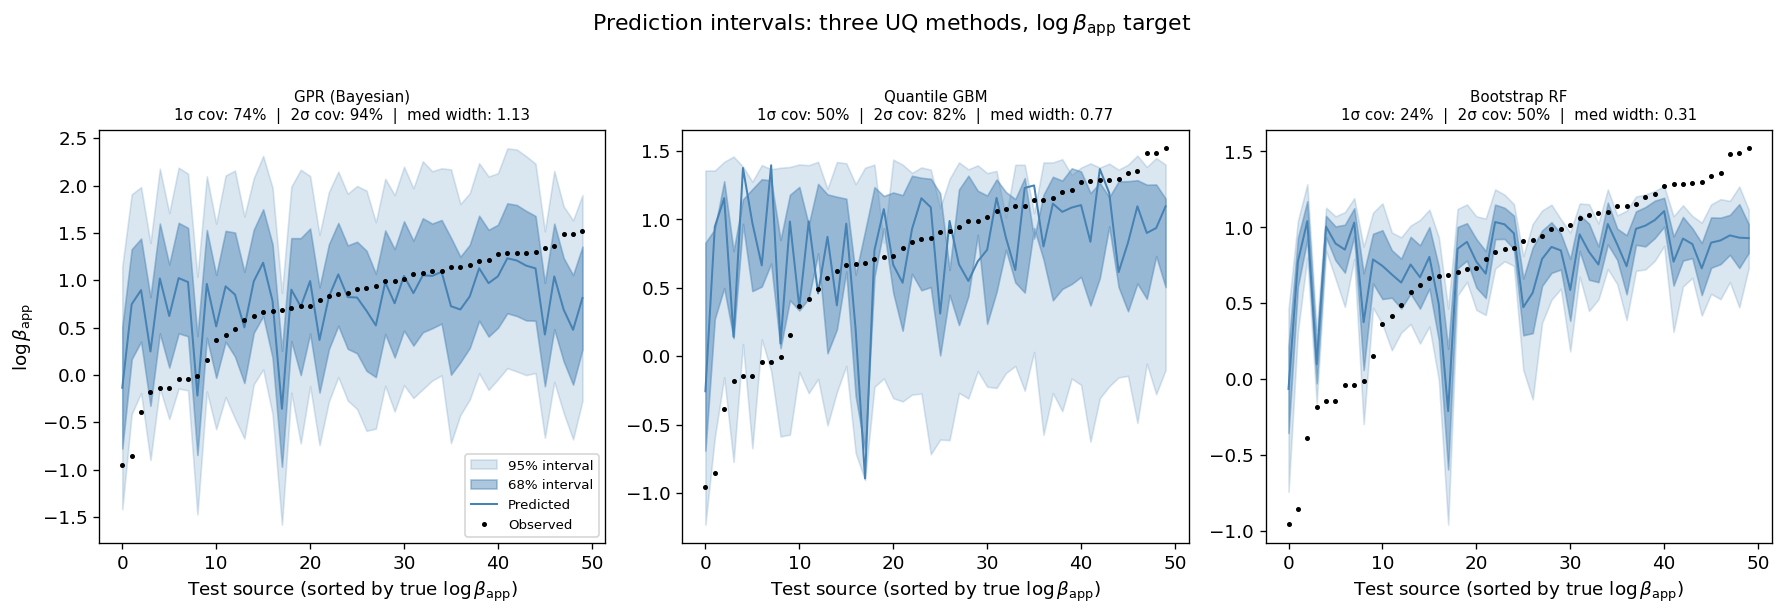

In [32]:
# ── Prediction intervals sorted by true value ──────────────────────────────────
order = np.argsort(y_test)
x_idx = np.arange(len(order))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, m) in zip(axes, uq_methods.items()):
    ax.fill_between(
        x_idx, m["lo2"][order], m["hi2"][order],
        alpha=0.20, color="steelblue", label="95% interval",
    )
    ax.fill_between(
        x_idx, m["lo1"][order], m["hi1"][order],
        alpha=0.45, color="steelblue", label="68% interval",
    )
    ax.plot(x_idx, m["center"][order], color="steelblue", lw=1.2, label="Predicted")
    ax.plot(x_idx, y_test[order], "k.", ms=4, zorder=5, label="Observed")
    cov1 = np.mean((y_test >= m["lo1"]) & (y_test <= m["hi1"]))
    cov2 = np.mean((y_test >= m["lo2"]) & (y_test <= m["hi2"]))
    w1 = float(np.median(m["hi1"] - m["lo1"]))
    ax.set_title(
        f"{name}\n1σ cov: {cov1:.0%}  |  2σ cov: {cov2:.0%}  |  med width: {w1:.2f}",
        fontsize=9,
    )
    ax.set_xlabel(r"Test source (sorted by true $\log \beta_{\rm app}$)")
    if ax is axes[0]:
        ax.set_ylabel(r"$\log \beta_{\rm app}$")
        ax.legend(fontsize=8)

plt.suptitle(r"Prediction intervals: three UQ methods, $\log \beta_{\rm app}$ target", y=1.02)
plt.tight_layout()
plt.show()